In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/code/compositional`


In [2]:
using DataFrames, JLD2, StatsBase, Distributions, Random
using CSV, CodecZlib
using CairoMakie, MakiePublication
using LsqFit, DataStructures

In [3]:
include("./utils.jl")
using .Utils

In [4]:
# Import Star Wars transcripts
folder = "./Data/Transcripts_raw/transcripts"
files = filter(f -> occursin("Star Wars", f) && endswith(f, ".txt"), readdir(folder))
data = Dict(f => read(joinpath(folder, f), String) for f in files);

In [5]:
keys_map = Dict(i => k for (i,k) in enumerate(keys(data)))
inv_keys_map = Dict(v => k for (k,v) in keys_map);

In [6]:
# Convert full text into array of words
raw_samples = Dict()
for (k,v) in data
    text = lowercase(v)
    words = filter(!isempty, split(text, r"[^A-Za-z]+"))
    raw_samples[k] = words
end

# Compute word counts
samples = Dict()
for (k,v) in raw_samples
    samples[inv_keys_map[k]] = countmap(v)
end

# Flatten into df
df = DataFrame(
    species_id = String[],
    sample_id = Int[],
    count = Int[],
    nreads = Int[],
)

for (sample, species_dict) in samples
    nreads = sum(values(species_dict))
    for (species, count) in species_dict
        push!(df, (species, sample, count, nreads))
    end
end

df.env .= "SW"

# remove stop words
STOPWORDS = Set([
    "me","my","myself","we","our","ours","ourselves","you","your","yours","yourself","yourselves","he","him","his","himself",
    "she","her","hers","herself","it","its","itself","hey","them","their","theirs","themselves","what","which","who","whom",
    "this","that","these","those","am","is","are","was","were","be","been","being","have","has","had","having","do","does","did",
    "doing","an","the","and","but","if","or","because","as","until","while","of","at","by","for","with","about","against","between",
    "into","through","during","before","after","above","below","to","from","up","down","in","out","on","off","over","under","again",
    "further","then","once","here","there","when","where","why","how","all","any","both","each","few","more","most","other","some",
    "such","no","nor","not","only","own","same","so","than","too","very","can","will","just","don","should","now",
    "a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v", "w","x","y","z"
])

df = filter(row -> !(lowercase(row.species_id) in STOPWORDS), df);

In [7]:
# Compute AFD
afd = Utils.compute_AFD(df; occ=0.95, bins=30, plot=false, verbose=true, save=false)
afd = afd["SW"];

SW


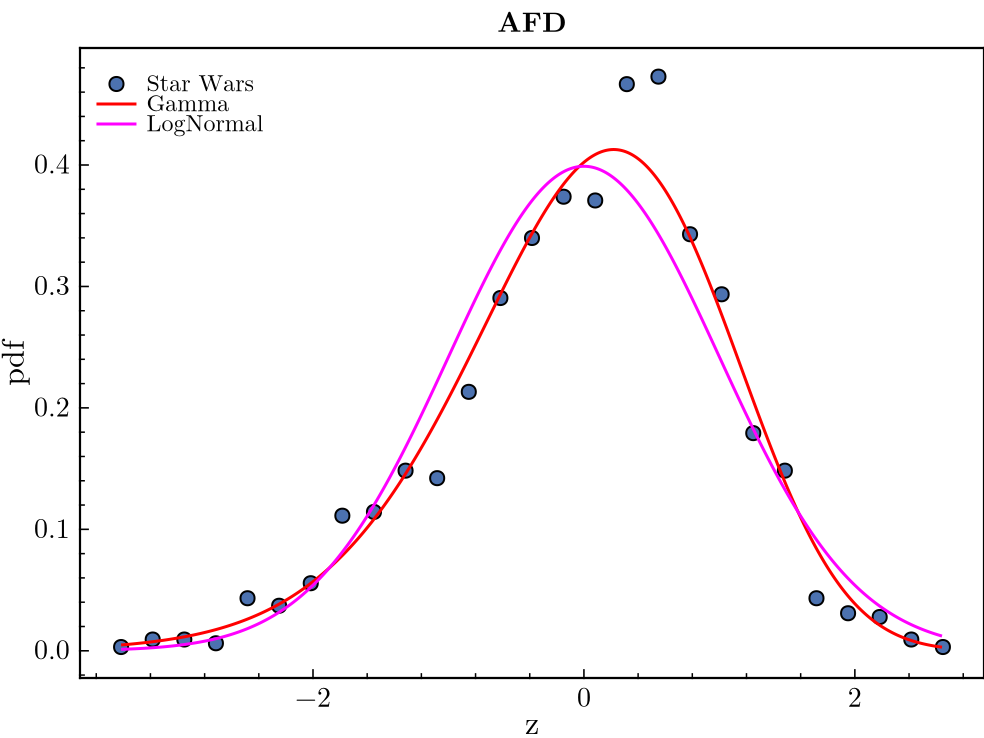

In [11]:
# Plot AFD
__theme = MakiePublication.theme_acs(; ishollowmarkers=[true,true])
set_theme!(__theme)

fig_hsize = 246 * 2
fig = Figure(size=(fig_hsize, fig_hsize * 3 / 4))

ax = Axis(fig[1,1], #yscale=log10,
        title = "AFD", xlabel=L"\text{z}", ylabel=L"\text{pdf}",
        xlabelsize=16, ylabelsize=16, titlesize=14,
        xticklabelsize=14, yticklabelsize=14
        )

x, y = afd
scatter!(ax, x, y, markersize=10, label="Star Wars")

zrange = minimum(x):1e-2:maximum(x)


lines!(ax, zrange, exp.(Utils.gamma(zrange, 5)), color=:red, label="Gamma")
lines!(ax, zrange, exp.(Utils.lognormal(zrange, 1)), color=:magenta, label="LogNormal")

axislegend(ax, position=:lt, framevisible=false, labelsize=12)

fig